In [116]:
import warnings
warnings.filterwarnings("ignore")

In [117]:
from pathlib import Path
from utils import *

import os
import sys
import logging
import warnings

import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import decoupler

from io import BytesIO
import base64
from IPython.display import HTML, display

## Config

In [118]:
MICE_DATASET_PATH = (
    r"/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/"
    r"integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad"
)

MALE_METACELL_PATH = r"/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/seacells_M_FastIIB_FastIIX_harmonyv2.h5ad"
FEMALE_METACELL_PATH = r"/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/seacells_F_FastIIB_FastIIX_harmonyv2.h5ad"


def get_mice_dataset_by_sex(cell_types=[], subset=True):
    # load anndata object
    adata = sc.read_h5ad(MICE_DATASET_PATH)

    # if subset is not specified, return the entire dataset
    if not subset:
        return adata

    # create subset based on cell types
    adata_processed = adata[adata.obs["C_scANVI"].isin(cell_types)].copy()

    # classify based on sex
    adata_male = adata_processed[adata_processed.obs["sex"] == "M"].copy()
    adata_female = adata_processed[adata_processed.obs["sex"] == "F"].copy()

    # return male and female dataset
    return adata_male.copy(), adata_female.copy()


def get_skeletal_muscle_metacell_dataset():
    # read male and female datasets
    metacell_male_adata = sc.read_h5ad(MALE_METACELL_PATH)
    metacell_female_adata = sc.read_h5ad(FEMALE_METACELL_PATH)

    # create condition column
    metacell_male_adata.obs["condition"] = metacell_male_adata.obs["y"].map({0: "WT", 1: "KO"})
    metacell_female_adata.obs["condition"] = metacell_female_adata.obs["y"].map({0: "WT", 1: "KO"})

    # create C_scANVI column
    metacell_male_adata.obs["C_scANVI"] = "Type II"
    metacell_female_adata.obs["C_scANVI"] = "Type II"

    # return male and female dataset
    return metacell_male_adata, metacell_female_adata

In [119]:
def get_senmayo_geneset(is_mice=True):
    # load senmayo geneset
    senmayo_geneset_path = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/SAUL_SEN_MAYO_UP_IN_SEN.v2024.1.Mm.gmt'

    # process geneset for decoupler input
    senmayo_geneset_up_decoupler_input = gmt_to_decoupler(senmayo_geneset_path)

    # rename columns to source and target
    senmayo_geneset_up_decoupler_input = senmayo_geneset_up_decoupler_input.rename(columns={"geneset": "source", "genesymbol": "target"})

    # format genes
    if is_mice:
        senmayo_geneset_up_decoupler_input["target"] = senmayo_geneset_up_decoupler_input["target"].str.capitalize()
    else:
        senmayo_geneset_up_decoupler_input["target"] = senmayo_geneset_up_decoupler_input["target"].str.upper()

    # return senmayo geneset
    return senmayo_geneset_up_decoupler_input


def get_sensig_geneset(is_mice=True):
    # load sensig geneset
    sensig_geneset_path = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/SenSig_DEGs.csv'
    sensig_genes = pd.read_csv(sensig_geneset_path, skiprows=1)

    # only get up genes
    sensig_up_genes = sensig_genes[sensig_genes['logFC'] > 0]['Gene'].to_list()

    # create decoupler input formatted df
    sensig_up_genes_decoupler_input = pd.DataFrame({
        "source": ["SENSIG"] * len(sensig_up_genes),
        "target": sensig_up_genes
    })

    # drop duplicates
    sensig_up_genes_decoupler_input = sensig_up_genes_decoupler_input.drop_duplicates(subset="target")

    # format genes
    if is_mice:
        sensig_up_genes_decoupler_input["target"] = sensig_up_genes_decoupler_input["target"].str.capitalize()
    else:
        sensig_up_genes_decoupler_input["target"] = sensig_up_genes_decoupler_input["target"].str.upper()

    # return sensig geneset
    return sensig_up_genes_decoupler_input


def get_gobp_dna_repair_geneset(is_mice=True):
    # load GOBP DNA Damage Repair 
    gobp_dna_damage_repair_path = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/dna_damage/GOBP_DNA_REPAIR.v2026.1.Mm.gmt"

    # process geneset for decoupler input
    gobp_dna_damage_repair_decoupler_input = gmt_to_decoupler(gobp_dna_damage_repair_path)

    # rename columns to source and target
    gobp_dna_damage_repair_decoupler_input = gobp_dna_damage_repair_decoupler_input.rename(columns={"geneset": "source", "genesymbol": "target"})

    # format genes
    if is_mice:
        gobp_dna_damage_repair_decoupler_input["target"] = gobp_dna_damage_repair_decoupler_input["target"].str.capitalize()
    else:
        gobp_dna_damage_repair_decoupler_input["target"] = gobp_dna_damage_repair_decoupler_input["target"].str.upper()

    # return gobp dna repair geneset
    return gobp_dna_damage_repair_decoupler_input


def get_gobp_dna_damage_response_geneset(is_mice=True):
    # load GOBP DNA Damage Response
    gobp_dna_damage_response_path = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/dna_damage/GOBP_DNA_DAMAGE_RESPONSE.v2026.1.Mm.gmt"

    # process geneset for decoupler input
    gobp_dna_damage_response_decoupler_input = gmt_to_decoupler(gobp_dna_damage_response_path)

    # rename columns to source and target
    gobp_dna_damage_response_decoupler_input = gobp_dna_damage_response_decoupler_input.rename(columns={"geneset": "source", "genesymbol": "target"})

    # format genes
    if is_mice:
        gobp_dna_damage_response_decoupler_input["target"] = gobp_dna_damage_response_decoupler_input["target"].str.capitalize()
    else:
        gobp_dna_damage_response_decoupler_input["target"] = gobp_dna_damage_response_decoupler_input["target"].str.upper()

    # return gobp dna damage response geneset
    return gobp_dna_damage_response_decoupler_input


def get_sarcomeric_geneset(is_mice=True):
    # load sarcomeric geneset
    sarcomeric_geneset_string = "ACTA1 ACTA2 ACTC1 ACTG1 ACTN4 ACTN2 ACTN3 DES DMD MYBPC1 MYBPC2 MYBPC3 MYH3 MYH6 MYH8 MYL1 MYL2 MYL3 MYL4 NEB TMOD1 TNNC2 TNNC1 TNNI1 TNNI2 TNNI3 TNNT1 TNNT2 TNNT3 TPM1 TPM2 TPM3 TPM4 TTN VIM TCAP MYOM1 MYL9"
    sarcomeric_geneset_list = sarcomeric_geneset_string.split()

    # create decoupler input formatted df
    sarcomeric_geneset_decoupler_input = pd.DataFrame({
        "source": ["SARCOMERIC"] * len(sarcomeric_geneset_list),
        "target": sarcomeric_geneset_list
    })

    # drop duplicates
    sarcomeric_geneset_decoupler_input = sarcomeric_geneset_decoupler_input.drop_duplicates(subset="target")

    # format genes
    if is_mice:
        sarcomeric_geneset_decoupler_input["target"] = sarcomeric_geneset_decoupler_input["target"].str.capitalize()
    else:
        sarcomeric_geneset_decoupler_input["target"] = sarcomeric_geneset_decoupler_input["target"].str.upper()

    # return sarcomeric geneset
    return sarcomeric_geneset_decoupler_input


def get_inflammation_geneset(is_mice=True):
    # load inflammation geneset
    inflammation_geneset_string = "Ccl2 Ccl3 Ccl3l1 Ccl4 Ccl4l2 Ccl5 Ccl14 Ccl21 Ccl23 Ccl28 Cxcl1 Cxcl2 Cxcl3 Cxcl6 Cxcl8 Cxcl12 Cxcl14 Cxcl16 Cx3cl1 Xcl1 Xcl2 Il1b Il1rn Il6st Il7 Il10 Il15 Il16 Il18 Il32 Il33 Il34 Ifng Tnf Lta Ltb Tnfsf10 Tnfsf12 Tnfsf13b Tnfsf14 Csf1 C3 C5 Tslp"
    inflammation_geneset_list = inflammation_geneset_string.split()

    # create decoupler input formatted df
    inflammation_geneset_decoupler_input = pd.DataFrame({
        "source": ["INFLAMMATION"] * len(inflammation_geneset_list),
        "target": inflammation_geneset_list
    })

    # drop duplicates
    inflammation_geneset_decoupler_input = inflammation_geneset_decoupler_input.drop_duplicates(subset="target")

    # format genes
    if is_mice:
        inflammation_geneset_decoupler_input["target"] = inflammation_geneset_decoupler_input["target"].str.capitalize()
    else:
        inflammation_geneset_decoupler_input["target"] = inflammation_geneset_decoupler_input["target"].str.upper()

    # return inflammation geneset
    return inflammation_geneset_decoupler_input


def get_gobp_branched_chain_amino_acid_metabolic_process_geneset(is_mice=True):
    # load anndata object
    filepath = r"/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/GOBP_BRANCHED_CHAIN_AMINO_ACID_METABOLIC_PROCESS.v2025.1.Hs.gmt"

    # create decoupler formatted df
    decoupler_input = gmt_to_decoupler(filepath)

    # rename columns
    decoupler_input = decoupler_input.rename(columns={"geneset": "source", "genesymbol": "target"})

    # format genes
    if is_mice:
        decoupler_input["target"] = decoupler_input["target"].str.capitalize()
    else:
        decoupler_input["target"] = decoupler_input["target"].str.upper()

    # return gobp dna damage response geneset
    return decoupler_input



def get_gobp_fatty_acid_beta_oxidation_geneset(is_mice=True):
    # load anndata object
    filepath = r"/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/GOBP_FATTY_ACID_BETA_OXIDATION.v2024.1.Hs.gmt"

    # create decoupler formatted df
    decoupler_input = gmt_to_decoupler(filepath)

    # rename columns
    decoupler_input = decoupler_input.rename(columns={"geneset": "source", "genesymbol": "target"})

    # format genes
    if is_mice:
        decoupler_input["target"] = decoupler_input["target"].str.capitalize()
    else:
        decoupler_input["target"] = decoupler_input["target"].str.upper()

    # return gobp dna damage response geneset
    return decoupler_input



def get_kegg_citrate_cycle_tca_cycle_geneset(is_mice=True):
    # load anndata object
    filepath = r"/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_CITRATE_CYCLE_TCA_CYCLE.v2024.1.Hs.gmt"

    # create decoupler formatted df
    decoupler_input = gmt_to_decoupler(filepath)

    # rename columns
    decoupler_input = decoupler_input.rename(columns={"geneset": "source", "genesymbol": "target"})

    # format genes
    if is_mice:
        decoupler_input["target"] = decoupler_input["target"].str.capitalize()
    else:
        decoupler_input["target"] = decoupler_input["target"].str.upper()

    # return gobp dna damage response geneset
    return decoupler_input



def get_kegg_glycolysis_gluconeogenesis_geneset(is_mice=True):
    # load anndata object
    filepath = r"/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_GLYCOLYSIS_GLUCONEOGENESIS.v2024.1.Hs.gmt"

    # create decoupler formatted df
    decoupler_input = gmt_to_decoupler(filepath)

    # rename columns
    decoupler_input = decoupler_input.rename(columns={"geneset": "source", "genesymbol": "target"})

    # format genes
    if is_mice:
        decoupler_input["target"] = decoupler_input["target"].str.capitalize()
    else:
        decoupler_input["target"] = decoupler_input["target"].str.upper()

    # return gobp dna damage response geneset
    return decoupler_input



def get_kegg_oxidative_phospholyration_geneset(is_mice=True):
    # load anndata object
    filepath = r"/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_OXIDATIVE_PHOSPHORYLATION.v2024.1.Hs.gmt"

    # create decoupler formatted df
    decoupler_input = gmt_to_decoupler(filepath)

    # rename columns
    decoupler_input = decoupler_input.rename(columns={"geneset": "source", "genesymbol": "target"})

    # format genes
    if is_mice:
        decoupler_input["target"] = decoupler_input["target"].str.capitalize()
    else:
        decoupler_input["target"] = decoupler_input["target"].str.upper()

    # return gobp dna damage response geneset
    return decoupler_input



def get_reactome_branched_chain_amino_acid_catabolism_geneset(is_mice=True):
    # load anndata object
    filepath = r"/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM.v2024.1.Hs.gmt"

    # create decoupler formatted df
    decoupler_input = gmt_to_decoupler(filepath)

    # rename columns
    decoupler_input = decoupler_input.rename(columns={"geneset": "source", "genesymbol": "target"})

    # format genes
    if is_mice:
        decoupler_input["target"] = decoupler_input["target"].str.capitalize()
    else:
        decoupler_input["target"] = decoupler_input["target"].str.upper()

    # return gobp dna damage response geneset
    return decoupler_input


def get_reactome_glutamate_and_glutamine_metabolism_geneset(is_mice=True):
    # load anndata object
    filepath = r"/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM.v2024.1.Hs.gmt"

    # create decoupler formatted df
    decoupler_input = gmt_to_decoupler(filepath)

    # rename columns
    decoupler_input = decoupler_input.rename(columns={"geneset": "source", "genesymbol": "target"})

    # format genes
    if is_mice:
        decoupler_input["target"] = decoupler_input["target"].str.capitalize()
    else:
        decoupler_input["target"] = decoupler_input["target"].str.upper()

    # return gobp dna damage response geneset
    return decoupler_input

In [120]:
"""
C_scANVI
Fast IIX         34128
Fast IIB         33378
MTJ               5034
EC                3263
FAPs              2830
Skeleton MuSc     2077
Pericyte          1970
Tendon            1958
NMJ               1066
Macrophages        968
"""
# specify dataset subset
cell_types=["Fast IIX"]

# get data
adata_male, adata_female = get_mice_dataset_by_sex(cell_types=cell_types)

In [121]:
# specify geneset
geneset = get_reactome_glutamate_and_glutamine_metabolism_geneset(is_mice=True)

In [122]:
# get title
violin_plot_male = f"Male {cell_types[0]}: {geneset['source'][0]}"
violin_plot_female = f"Female {cell_types[0]}: {geneset['source'][0]}"

# filepath
save_filepath = rf"/ocean/projects/cis240075p/ageorge3/tasks/geneset_analysis/images/mice_{cell_types[0]}_{geneset['source'][0]}.png"

## Dataset

In [123]:
# verify
print("male: ")
display(adata_male.obs["C_scANVI"].value_counts())
print("female: ")
display(adata_female.obs["C_scANVI"].value_counts())


male: 


C_scANVI
Fast IIX    15301
Name: count, dtype: int64

female: 


C_scANVI
Fast IIX    18827
Name: count, dtype: int64

## Geneset

In [124]:
# verify
display(geneset.head())
print(f"number of genes: {len(geneset)}")

# list of genes
genes_list = geneset["target"].to_list()

# in male data
male_present_genes = set(genes_list) & set(adata_male.var_names)
print(f"number of genes present in male: {len(male_present_genes)}")

# in female data
female_present_genes = set(genes_list) & set(adata_female.var_names)
print(f"number of genes present female: {len(female_present_genes)}")

,source,target
0,REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM,Aldh18a1
1,REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM,Gls
2,REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM,Gls2
3,REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM,Glud1
4,REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM,Glud2


number of genes: 14
number of genes present in male: 2
number of genes present female: 2


## Scoring

In [125]:
# get geneset name
pathways = [geneset["source"].unique()[0]]
pathways

['REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM']

In [126]:
%%time
# male data
decoupler.mt.aucell(
    adata_male,
    geneset,
    raw=False,
    verbose=True
)

# check per cell scores
male_scores = adata_male.obsm["score_aucell"].copy()

# add pathways to .obs
for pathway in pathways:
    adata_male.obs[pathway] = male_scores[pathway]

# get male scores df for plotting
male_senescence_scores = adata_male.obs[["C_scANVI", "condition"] + pathways].copy()

# display male senescence scores
print("male: ")
display(male_senescence_scores.head())

2026-03-16 17:07:11 | [INFO] aucell - Running aucell
2026-03-16 17:07:11 | [INFO] Extracted omics mat with 15301 rows (observations) and 3000 columns (features)
2026-03-16 17:07:11 | [WARNING] 69 features of mat are empty, they will be removed
2026-03-16 17:07:11 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1


AssertionError: No sources with more than tmin=5 targets after
     filtering by shared features in mat.
     Make sure mat and net have shared target features or
     reduce the number assigned to tmin

In [127]:
%%time
# female data
decoupler.mt.aucell(
    adata_female,
    geneset,
    raw=False,
    verbose=True
)

# check per cell scores
female_scores = adata_female.obsm["score_aucell"].copy()

# add pathways to .obs
for pathway in pathways:
    adata_female.obs[pathway] = female_scores[pathway]

# get male scores df for plotting
female_senescence_scores = adata_female.obs[["C_scANVI", "condition"] + pathways].copy()

# display male senescence scores
print("female: ")
display(female_senescence_scores.head())

2026-03-16 17:07:11 | [INFO] aucell - Running aucell
2026-03-16 17:07:11 | [INFO] Extracted omics mat with 18827 rows (observations) and 3000 columns (features)
2026-03-16 17:07:12 | [WARNING] 50 features of mat are empty, they will be removed
2026-03-16 17:07:12 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1


AssertionError: No sources with more than tmin=5 targets after
     filtering by shared features in mat.
     Make sure mat and net have shared target features or
     reduce the number assigned to tmin

In [128]:
# get gene correlation to senescence for male KO
adata_male_ko = adata_male[(adata_male.obs["condition"] == "KO")].copy()

# calculate gene correlation
male_ko_gene_senescence_corr, male_ko_geneset_ranked_df = compute_gene_ranking(adata_male_ko,
                                                                               geneset["target"])

# get gene correlation to senescence for male WT
adata_male_wt = adata_male[(adata_male.obs["condition"] == "WT")].copy()

# calculate gene correlation
male_wt_gene_senescence_corr, male_wt_geneset_ranked_df = compute_gene_ranking(adata_male_wt,
                                                                               geneset["target"])

# get gene correlation to senescence for female KO
adata_female_ko = adata_female[(adata_female.obs["condition"] == "KO")].copy()

# calculate gene correlation
female_ko_gene_senescence_corr, female_ko_geneset_ranked_df = compute_gene_ranking(adata_female_ko,
                                                                               geneset["target"])

# get gene correlation to senescence for female WT
adata_female_wt = adata_female[(adata_female.obs["condition"] == "WT")].copy()

# calculate gene correlation
female_wt_gene_senescence_corr, female_wt_geneset_ranked_df = compute_gene_ranking(adata_female_wt,
                                                                               geneset["target"])

KeyError: 'score_aucell'

In [ ]:
# verify

print("male wt:")
display(male_wt_geneset_ranked_df.head())

print("male ko:")
display(male_wt_geneset_ranked_df.head())

print("female wt:")
display(female_wt_geneset_ranked_df.head())

print("female ko:")
display(female_ko_geneset_ranked_df.head())

male wt:


,gene,spearman_corr,rank
0,Acss2,0.647020,1
1,Hk2,0.607730,2
2,Ldhb,0.175054,4
3,Acss1,0.075563,40
4,Pck1,0.028744,158


male ko:


,gene,spearman_corr,rank
0,Acss2,0.647020,1
1,Hk2,0.607730,2
2,Ldhb,0.175054,4
3,Acss1,0.075563,40
4,Pck1,0.028744,158


female wt:


,gene,spearman_corr,rank
0,Hk2,0.764528,1
1,Acss2,0.509168,2
2,Ldhb,0.134703,16
3,Acss1,0.088608,43
4,Gck,0.051128,81


female ko:


,gene,spearman_corr,rank
0,Hk2,0.715739,1
1,Acss2,0.572556,2
2,Ldhb,0.151952,3
3,Acss1,0.051267,50
4,Pck1,0.015224,314


## Plotting


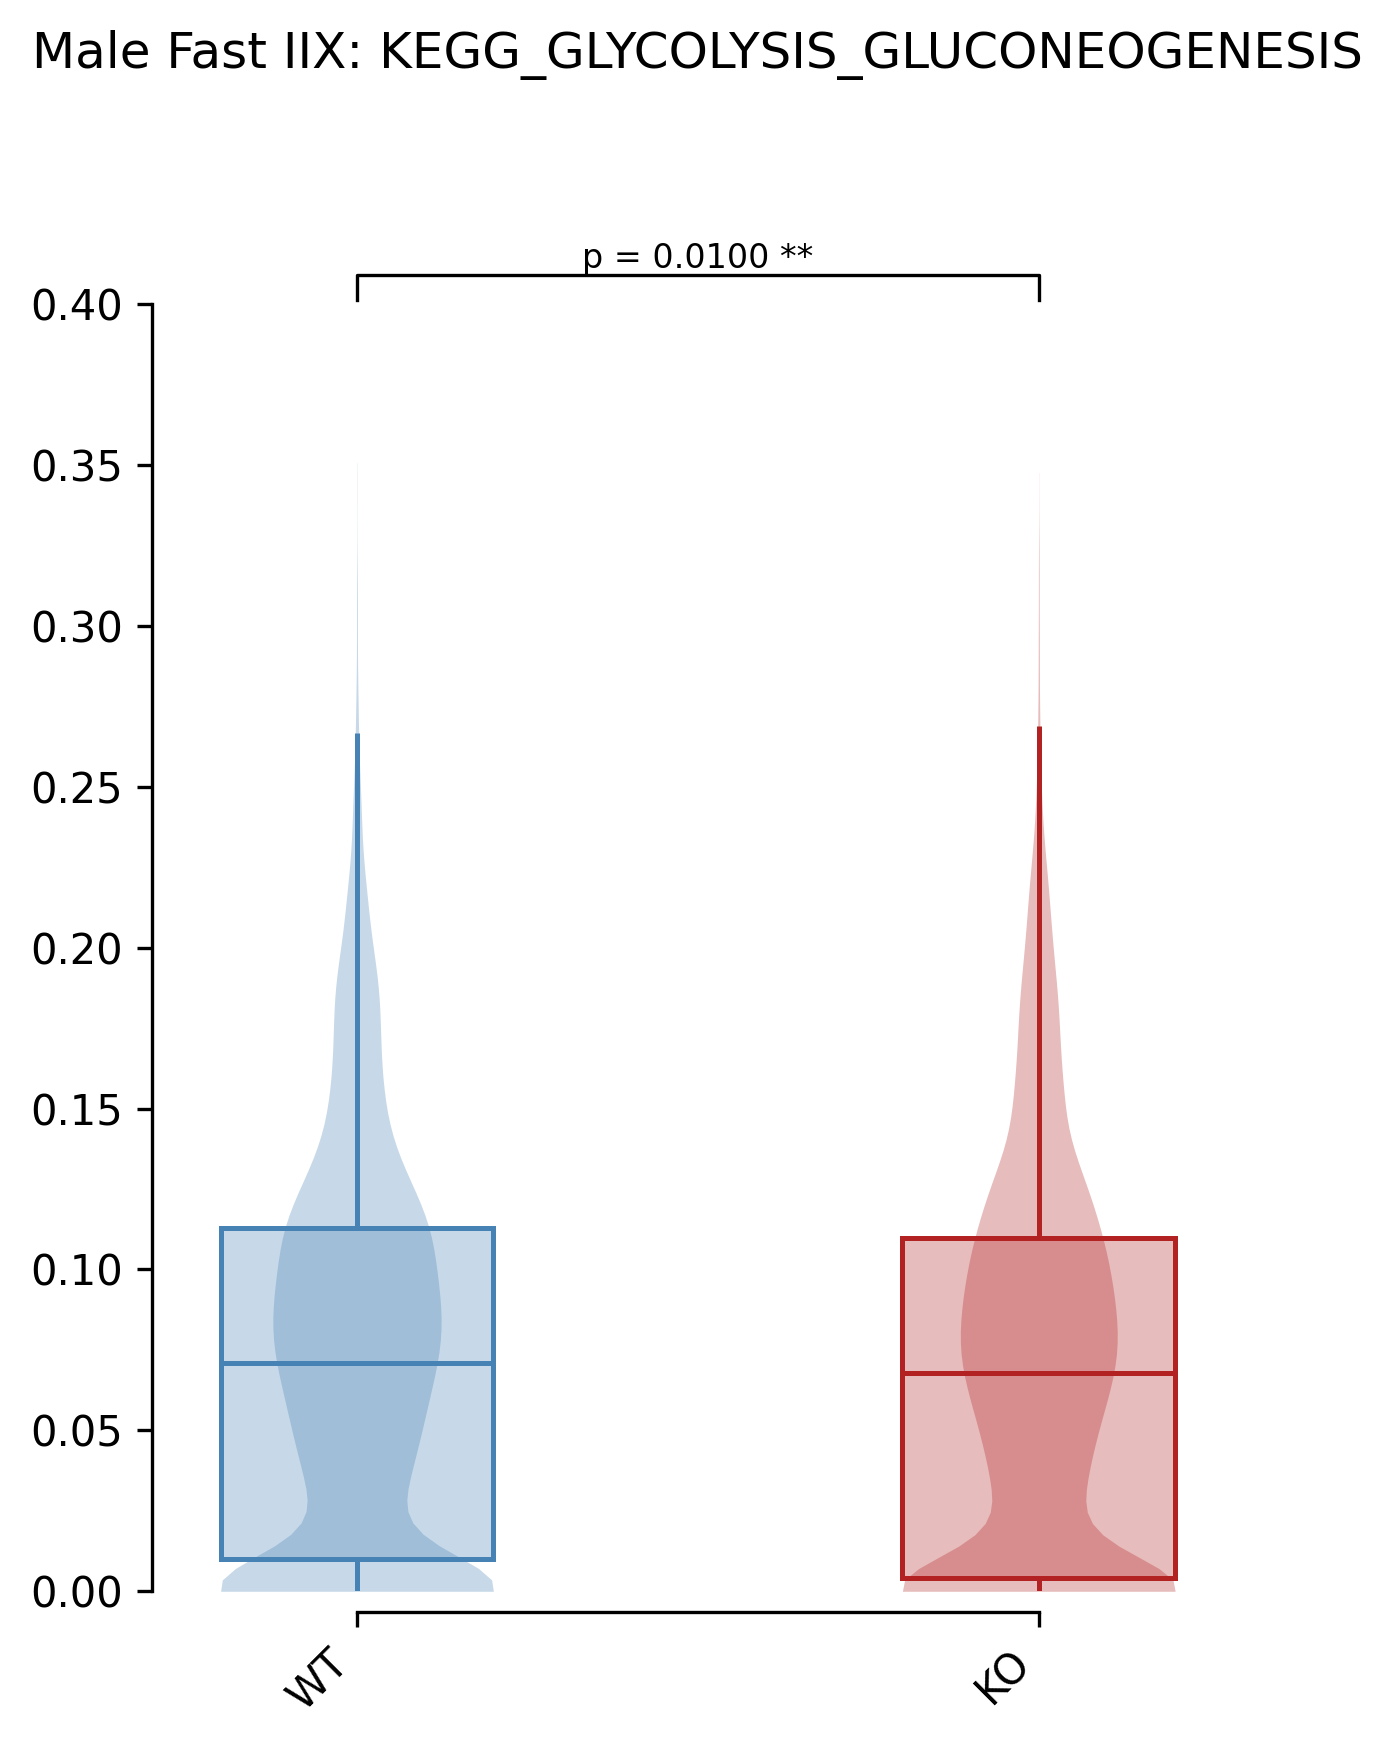
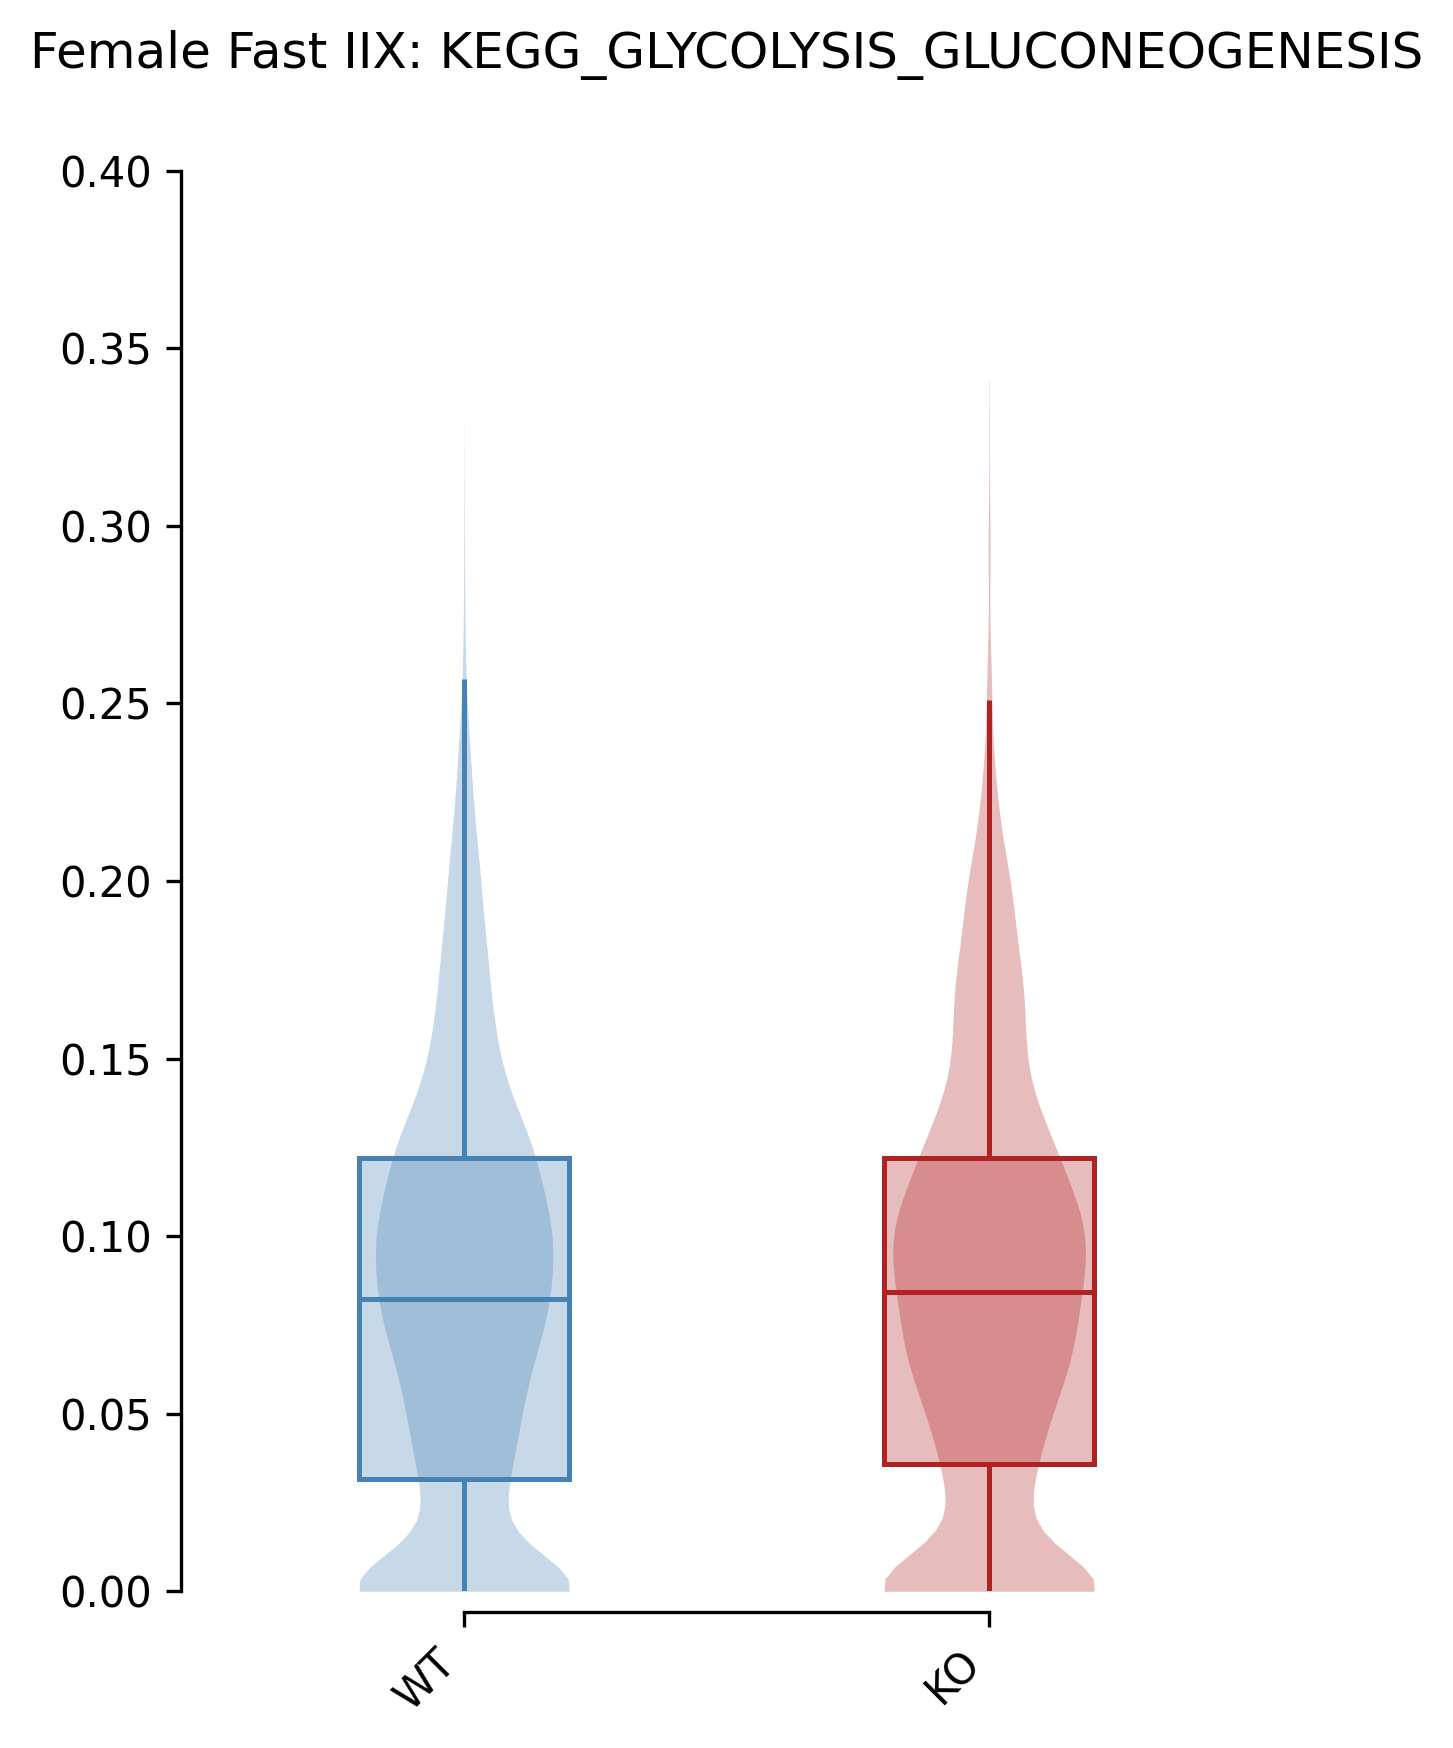
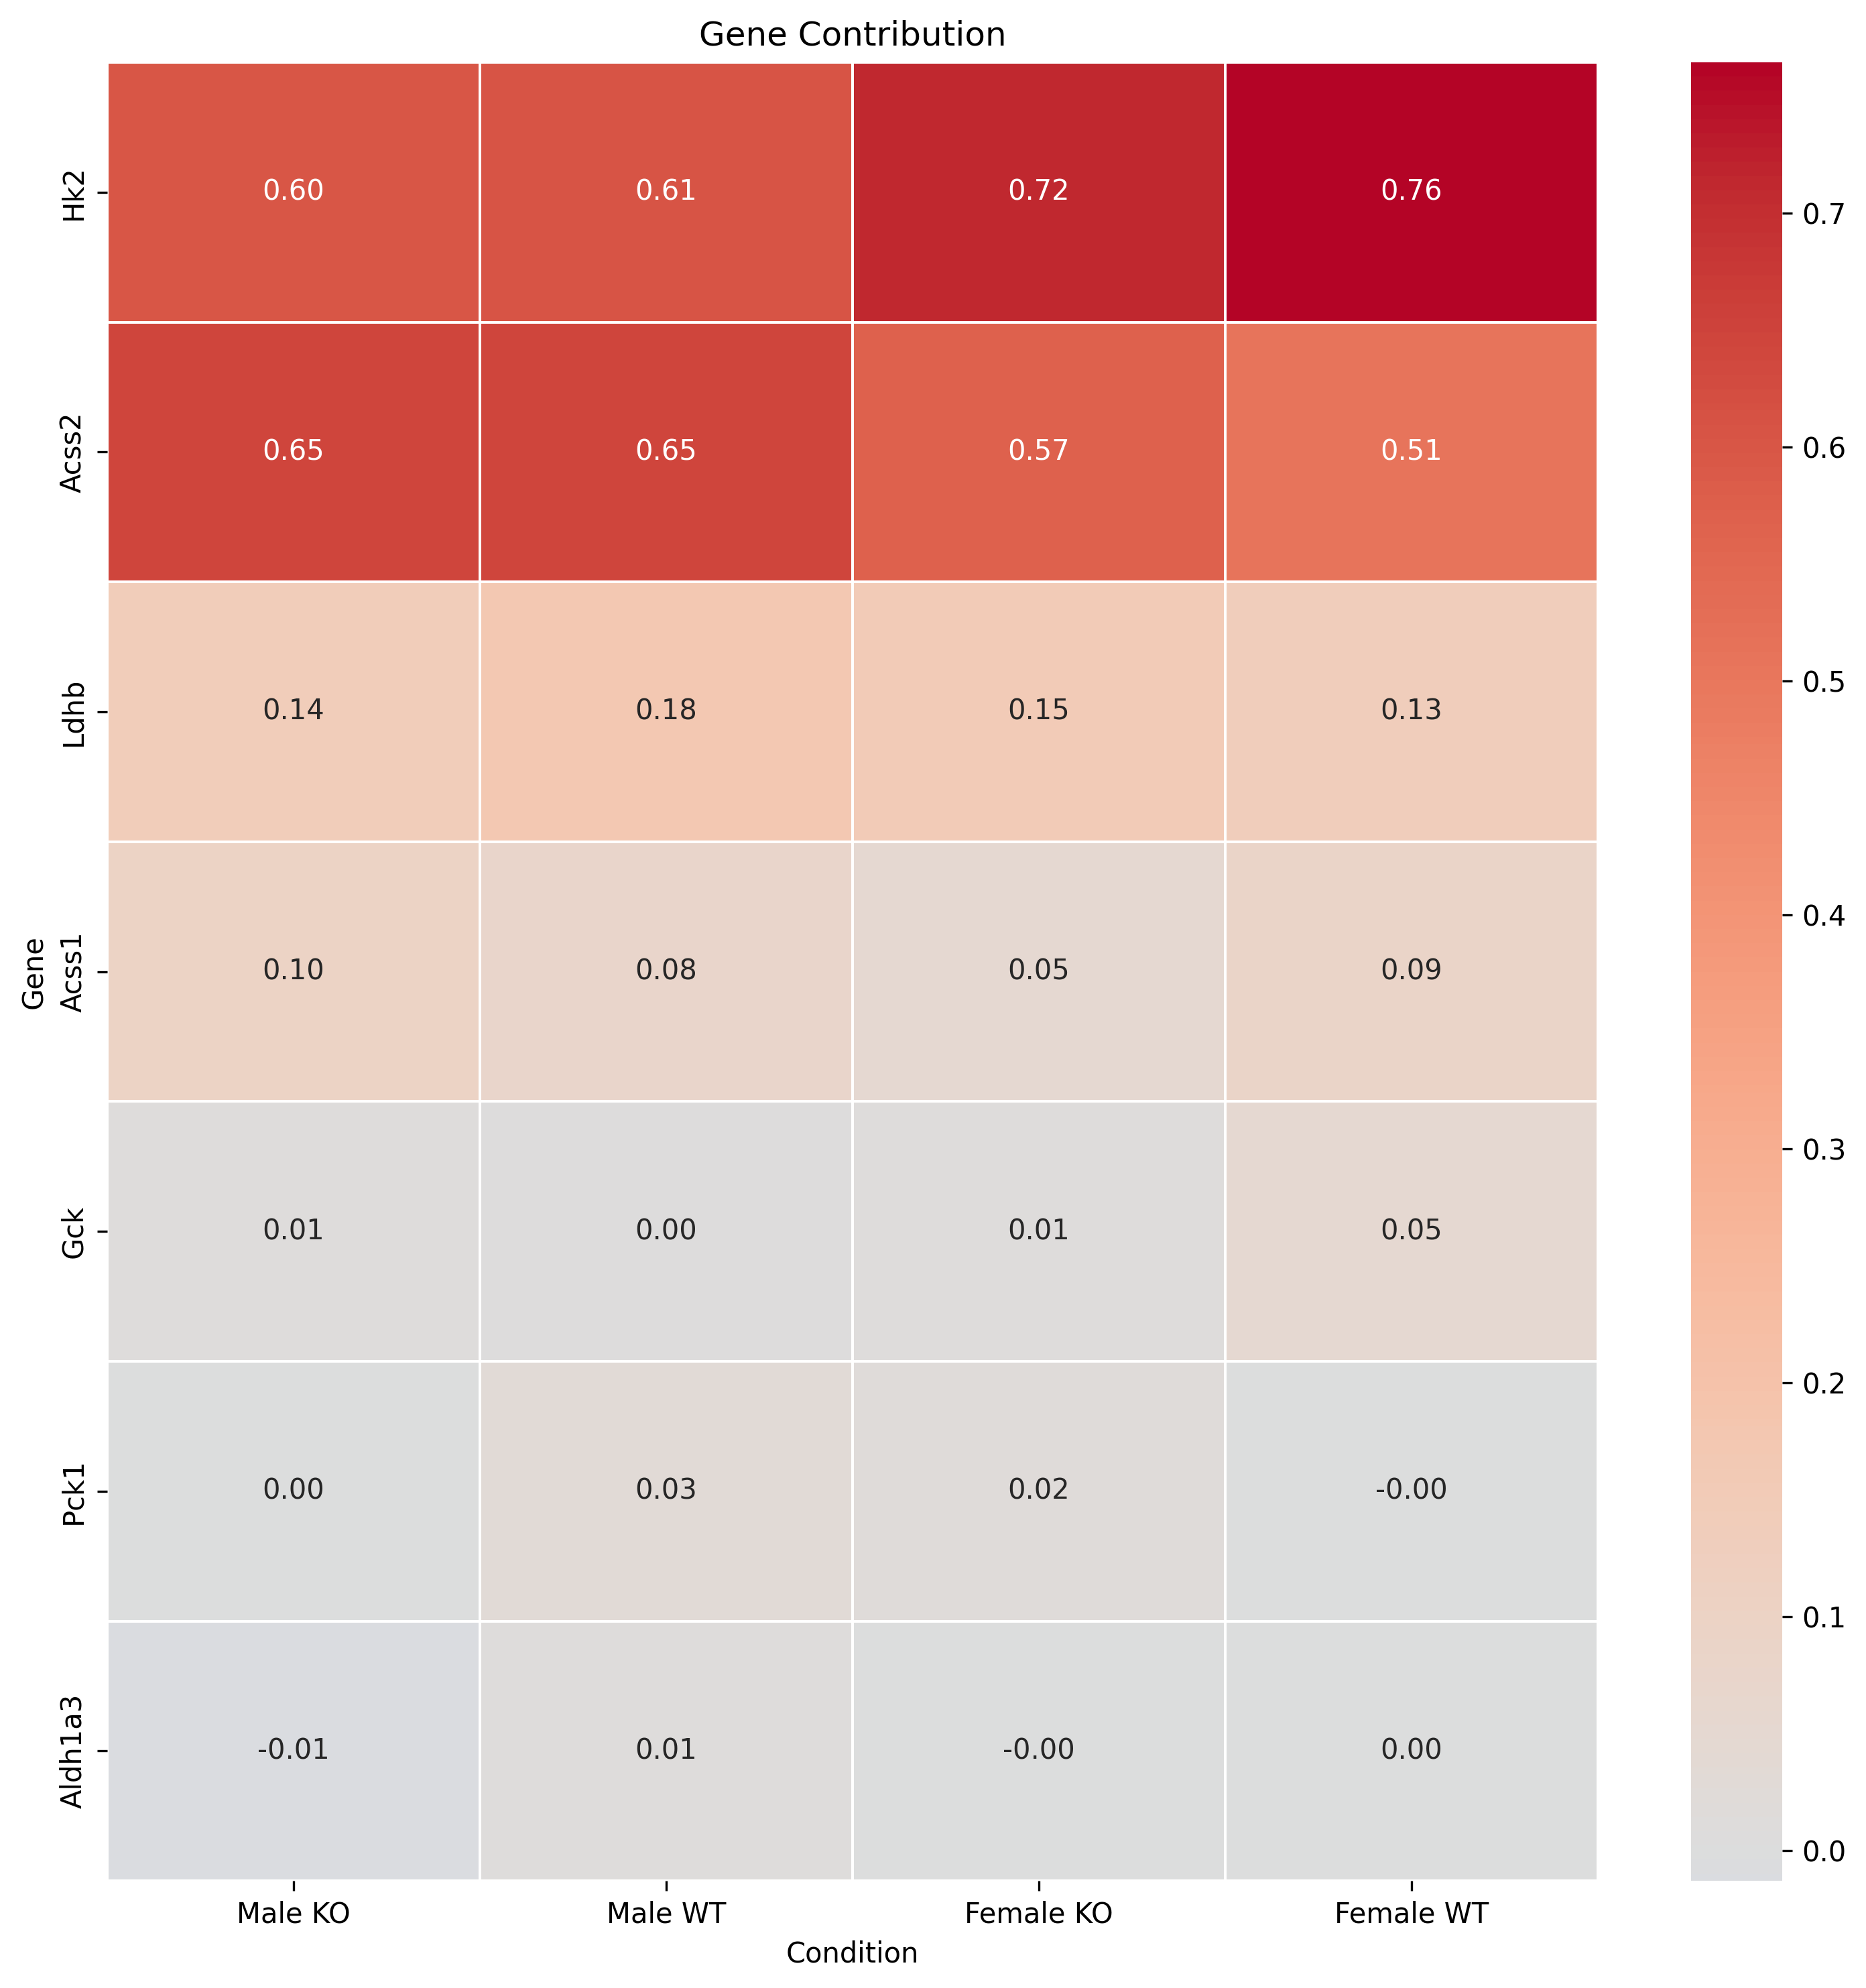

<Figure size 640x480 with 0 Axes>

In [ ]:
# violin-heatmap combo

custom_colors = {"WT":"steelblue", "KO":"firebrick"}

fig_male = plot_violin_box_combo(
    data=male_senescence_scores,
    x_var='condition',
    y_var=pathways[0],
    title=violin_plot_male,
    x_ticks=["WT", "KO"],
    palette=custom_colors,
    rotation=45,
    show_scatter=False
)

fig_female = plot_violin_box_combo(
    data=female_senescence_scores,
    x_var='condition',
    y_var=pathways[0],
    title=violin_plot_female,
    x_ticks=["WT", "KO"],
    palette=custom_colors,
    rotation=45,
    show_scatter=False
)

fig_gene_heatmap = plot_heatmap(male_ko_geneset_ranked_df,
                                male_wt_geneset_ranked_df,
                                female_ko_geneset_ranked_df,
                                female_wt_geneset_ranked_df,
                                title="Gene Contribution",
                                figsize=(10,10))

display_plots_side_by_side([fig_male, fig_female, fig_gene_heatmap], width=550, save_path=save_filepath)